# Artificial Bee Colony 人工蜂群算法

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验使用 **Ackley 函数**。蜂群算法可以很清楚地演示“开发现有优质蜜源”和“侦察新区域”这两种搜索行为。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


def objective(point):
    x, y = point
    term_1 = -20 * np.exp(-0.2 * np.sqrt(0.5 * (x ** 2 + y ** 2)))
    term_2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return term_1 + term_2 + np.e + 20

bounds = np.array([[-5, 5], [-5, 5]], dtype=float)

## 算法直觉

核心思想：雇佣蜂负责围绕当前蜜源局部开发，观察蜂根据蜜源质量分配搜索注意力，侦察蜂则负责跳到新区域重新探索。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
def artificial_bee_colony(objective, bounds, n_food_sources=18, limit=10, n_iterations=70, seed=0):
    rng = np.random.default_rng(seed)
    dim = len(bounds)

    foods = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_food_sources, dim))
    scores = np.apply_along_axis(objective, 1, foods)
    trial_counters = np.zeros(n_food_sources, dtype=int)

    history = [foods.copy()]
    best_scores = [float(scores.min())]

    def generate_neighbor(index):
        # 经典 ABC 近邻生成公式：沿着与另一食源的差向量方向进行扰动。
        partner_index = rng.choice([i for i in range(n_food_sources) if i != index])
        phi = rng.uniform(-1, 1, size=dim)
        candidate = foods[index] + phi * (foods[index] - foods[partner_index])
        return np.clip(candidate, bounds[:, 0], bounds[:, 1])

    for _ in range(n_iterations):
        # 第一阶段：雇佣蜂逐个尝试改进自己的食源。
        for i in range(n_food_sources):
            candidate = generate_neighbor(i)
            candidate_score = objective(candidate)
            if candidate_score < scores[i]:
                foods[i] = candidate
                scores[i] = candidate_score
                trial_counters[i] = 0
            else:
                trial_counters[i] += 1

        # 第二阶段：观察蜂按照适应度概率选择更有前景的食源进行开发。
        fitness = 1 / (1 + scores)
        probabilities = fitness / fitness.sum()
        for _ in range(n_food_sources):
            i = rng.choice(n_food_sources, p=probabilities)
            candidate = generate_neighbor(i)
            candidate_score = objective(candidate)
            if candidate_score < scores[i]:
                foods[i] = candidate
                scores[i] = candidate_score
                trial_counters[i] = 0
            else:
                trial_counters[i] += 1

        # 第三阶段：如果某个食源长期没有改进，就让侦察蜂重新随机发现新位置。
        for i in range(n_food_sources):
            if trial_counters[i] >= limit:
                foods[i] = rng.uniform(bounds[:, 0], bounds[:, 1])
                scores[i] = objective(foods[i])
                trial_counters[i] = 0

        history.append(foods.copy())
        best_scores.append(float(scores.min()))

    best_idx = int(np.argmin(scores))
    return {
        'best': foods[best_idx],
        'best_score': float(scores[best_idx]),
        'history': history,
        'best_scores': np.array(best_scores),
    }

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [ 0.002  -0.0055]
best score: 0.017478


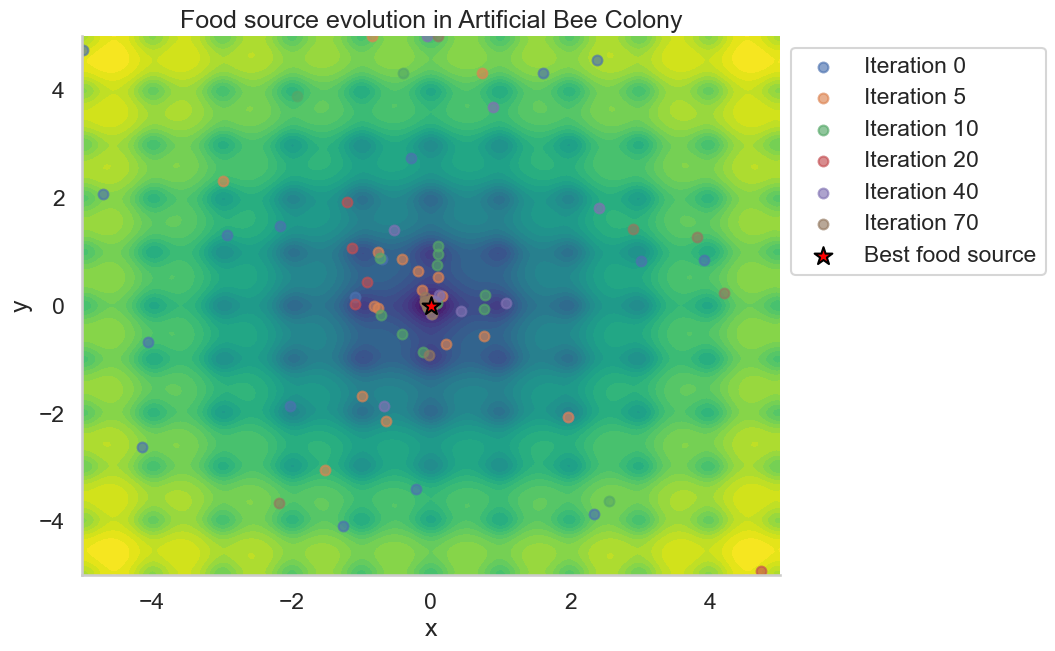

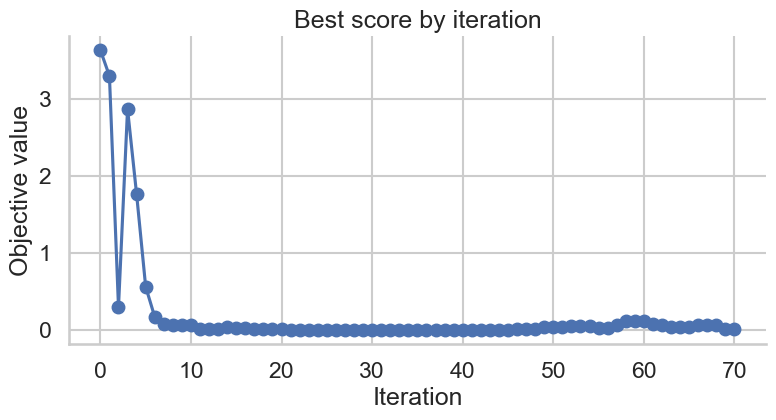

In [3]:
abc_result = artificial_bee_colony(objective, bounds, seed=3)
print('best point:', np.round(abc_result['best'], 4))
print('best score:', round(abc_result['best_score'], 6))

xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=40, cmap='viridis')
for idx in [0, 5, 10, 20, 40, 70]:
    foods = abc_result['history'][idx]
    plt.scatter(foods[:, 0], foods[:, 1], s=50, alpha=0.65, label=f'Iteration {idx}')
plt.scatter(abc_result['best'][0], abc_result['best'][1], color='red', s=180, marker='*', edgecolor='black', label='Best food source')
plt.title('Food source evolution in Artificial Bee Colony')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(abc_result['best_scores'], marker='o')
plt.title('Best score by iteration')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,Artificial Bee Colony statistics
best,2.749912e-08
mean,3.232053e-02
worst,1.310631e-01
std,4.362913e-02


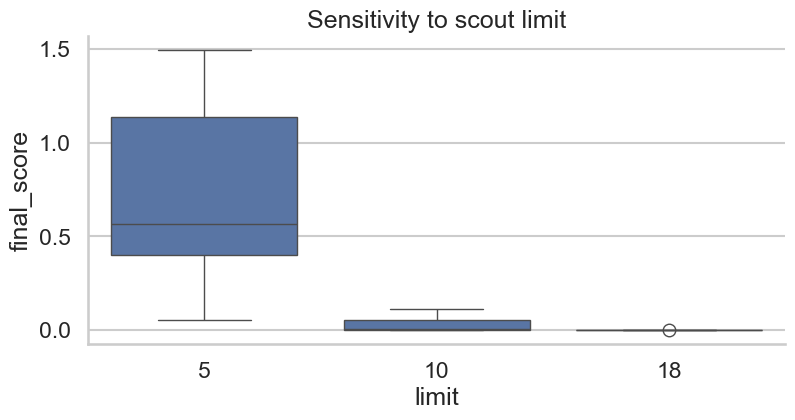

In [4]:
run_scores = [artificial_bee_colony(objective, bounds, seed=seed)['best_score'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Artificial Bee Colony statistics'))

limit_values = [5, 10, 18]
records = []
for limit in limit_values:
    for seed in range(10):
        score = artificial_bee_colony(objective, bounds, limit=limit, seed=seed)['best_score']
        records.append({'limit': limit, 'final_score': score})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='limit', y='final_score')
plt.title('Sensitivity to scout limit')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。